In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor#i need this since its lineair and curved
from sklearn.metrics import mean_squared_error
from sklearn.metrics import (
    confusion_matrix,           # The confusion matrix itself
    accuracy_score,              # Accuracy = (TP+TN)/(TP+TN+FP+FN)
    precision_score,             # Precision = TP/(TP+FP)
    recall_score,                # Recall = TP/(TP+FN)
    f1_score,                    # F1 = 2*(Precision*Recall)/(Precision+Recall)
    ConfusionMatrixDisplay,      # For visualizing confusion matrix
)
df=pd.read_csv("train (1).csv")
df1=pd.read_csv("test (1).csv")
print("hello hit hub ")
df

hello hit hub 


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [207]:
#dropping unnacessary features
id=df1["id"]#add it later
df.drop(["id"],axis=1,inplace=True)
df1.drop(["id"],axis=1,inplace=True)

In [208]:
#we scale the square footage columns, we use standardization 
df["Age"]=StandardScaler().fit_transform(df[["Age"]])
df["BP"]=StandardScaler().fit_transform(df[["BP"]])
df["Cholesterol"]=StandardScaler().fit_transform(df[["Cholesterol"]])
df["Max HR"]=StandardScaler().fit_transform(df[["Max HR"]])


df1["Age"]=StandardScaler().fit_transform(df1[["Age"]])
df1["BP"]=StandardScaler().fit_transform(df1[["BP"]])
df1["Cholesterol"]=StandardScaler().fit_transform(df1[["Cholesterol"]])
df1["Max HR"]=StandardScaler().fit_transform(df1[["Max HR"]])


In [209]:
# polyfeatures
df["bp2"]=df["BP"]*df["BP"]
df["bp3"]=df["BP"]*df["bp2"]


df["Cholesterol2"]=df["Cholesterol"]*df["Cholesterol"]
df["Cholesterol3"]=df["Cholesterol"]*df["Cholesterol2"]


df["Max HR2"]=df["Max HR"]*df["Max HR"]
df["Max HR3"]=df["Max HR"]*df["Max HR2"]



df["Age2"]=df["Age"]*df["Age"]
df["Age3"]=df["Age"]*df["Age2"]




df1["bp2"]=df1["BP"]*df1["BP"]
df1["bp3"]=df1["BP"]*df1["bp2"]


df1["Cholesterol2"]=df1["Cholesterol"]*df1["Cholesterol"]
df1["Cholesterol3"]=df1["Cholesterol"]*df1["Cholesterol2"]


df1["Max HR2"]=df1["Max HR"]*df1["Max HR"]
df1["Max HR3"]=df1["Max HR"]*df1["Max HR2"]



df1["Age2"]=df1["Age"]*df1["Age"]
df1["Age3"]=df1["Age"]*df1["Age2"]



In [210]:
df = pd.get_dummies(df, columns=["Chest pain type"], dtype=int)

df = pd.get_dummies(df, columns=["Sex"], dtype=int)

df = pd.get_dummies(df, columns=["Exercise angina"], dtype=int)

df = pd.get_dummies(df, columns=["Slope of ST"], dtype=int)

df = pd.get_dummies(df, columns=["EKG results"], dtype=int)

df = pd.get_dummies(df, columns=["Thallium"], dtype=int)




df1 = pd.get_dummies(df1, columns=["Chest pain type"], dtype=int)

df1 = pd.get_dummies(df1, columns=["Sex"], dtype=int)

df1 = pd.get_dummies(df1, columns=["Exercise angina"], dtype=int)

df1 = pd.get_dummies(df1, columns=["Slope of ST"], dtype=int)

df1 = pd.get_dummies(df1, columns=["EKG results"], dtype=int)

df1 = pd.get_dummies(df1, columns=["Thallium"], dtype=int)

In [211]:
df["Heart Disease"]=df["Heart Disease"].map({"Presence":0, "Absence":1})
df

,Age,BP,Cholesterol,FBS over 120,Max HR,ST depression,Number of vessels fluro,Heart Disease,bp2,bp3,...,Exercise angina_1,Slope of ST_1,Slope of ST_2,Slope of ST_3,EKG results_0,EKG results_1,EKG results_2,Thallium_3,Thallium_6,Thallium_7
0,0.467921,1.435822,-0.178490,0,0.271190,3.6,2,0,2.061584,2.960068,...,1,0,1,0,1,0,0,0,0,1
1,-0.258797,-0.367088,2.374837,0,0.951359,0.0,0,1,0.134754,-0.049466,...,0,1,0,0,0,0,1,1,0,0
2,0.225682,1.970017,-1.692672,0,-0.095054,0.0,0,1,3.880968,7.645575,...,0,1,0,0,0,0,1,1,0,0
3,-1.227755,0.233882,-0.475388,0,-0.147375,1.0,0,1,0.054701,0.012794,...,0,0,1,0,0,0,1,1,0,0
4,0.467921,0.634529,-0.326939,0,-1.455391,3.8,3,0,0.402627,0.255478,...,1,0,1,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,0.225682,-1.368705,-0.564458,0,-1.089147,0.0,0,1,1.873352,-2.564066,...,0,1,0,0,1,0,0,0,0,1
629996,-0.016558,-0.166765,0.118409,1,-0.147375,0.0,0,1,0.027810,-0.004638,...,0,0,1,0,0,0,1,1,0,0
629997,1.557998,-0.033216,0.890344,0,-0.199696,0.0,2,0,0.001103,-0.000037,...,0,1,0,0,1,0,0,0,0,1
629998,-0.258797,0.634529,-1.366083,0,0.218870,0.0,0,0,0.402627,0.255478,...,0,1,0,0,0,0,1,0,1,0


In [212]:
y=df[["Heart Disease"]]
df.drop(["Heart Disease"],axis=1,inplace=True)
df

,Age,BP,Cholesterol,FBS over 120,Max HR,ST depression,Number of vessels fluro,bp2,bp3,Cholesterol2,...,Exercise angina_1,Slope of ST_1,Slope of ST_2,Slope of ST_3,EKG results_0,EKG results_1,EKG results_2,Thallium_3,Thallium_6,Thallium_7
0,0.467921,1.435822,-0.178490,0,0.271190,3.6,2,2.061584,2.960068,0.031859,...,1,0,1,0,1,0,0,0,0,1
1,-0.258797,-0.367088,2.374837,0,0.951359,0.0,0,0.134754,-0.049466,5.639849,...,0,1,0,0,0,0,1,1,0,0
2,0.225682,1.970017,-1.692672,0,-0.095054,0.0,0,3.880968,7.645575,2.865138,...,0,1,0,0,0,0,1,1,0,0
3,-1.227755,0.233882,-0.475388,0,-0.147375,1.0,0,0.054701,0.012794,0.225994,...,0,0,1,0,0,0,1,1,0,0
4,0.467921,0.634529,-0.326939,0,-1.455391,3.8,3,0.402627,0.255478,0.106889,...,1,0,1,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,0.225682,-1.368705,-0.564458,0,-1.089147,0.0,0,1.873352,-2.564066,0.318613,...,0,1,0,0,1,0,0,0,0,1
629996,-0.016558,-0.166765,0.118409,1,-0.147375,0.0,0,0.027810,-0.004638,0.014021,...,0,0,1,0,0,0,1,1,0,0
629997,1.557998,-0.033216,0.890344,0,-0.199696,0.0,2,0.001103,-0.000037,0.792713,...,0,1,0,0,1,0,0,0,0,1
629998,-0.258797,0.634529,-1.366083,0,0.218870,0.0,0,0.402627,0.255478,1.866184,...,0,1,0,0,0,0,1,0,1,0


In [213]:
#improvments 
df["Cholesterol*bp"]=(df["Cholesterol"]+df["BP"])/2
df1["Cholesterol*bp"]=(df1["Cholesterol"]+df1["BP"])/2

In [214]:
model = LogisticRegression()

x_train,x_test,y_train,y_test=train_test_split(
    df,y,test_size=0.10,random_state=42, stratify=y
)
model.fit(x_train,y_train)  

# Get probability scores for positive class
y_pred_proba = model.predict_proba(x_test)[:, 1]  # probabilities for class 1

# Choose a lower threshold (e.g., 0.3 instead of default 0.5)
threshold = 0.9
y_pred_custom = (y_pred_proba >= threshold).astype(int)


C:\Users\PC\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [215]:
accuracy = accuracy_score(y_test,y_pred_custom)
precision = precision_score(y_test,y_pred_custom, pos_label=0)
recall = recall_score(y_test,y_pred_custom, pos_label=0)
f1 = f1_score(y_test,y_pred_custom, pos_label=0)

print("="*60)
print("📊 MODEL PERFORMANCE METRICS")
print("="*60)
print(f"✅ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"✅ Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"✅ F1-Score:  {f1:.4f} ({f1*100:.2f}%)")




📊 MODEL PERFORMANCE METRICS
✅ Accuracy:  0.7894 (78.94%)
✅ Precision: 0.6867 (68.67%)
✅ Recall:    0.9752 (97.52%)
✅ F1-Score:  0.8059 (80.59%)


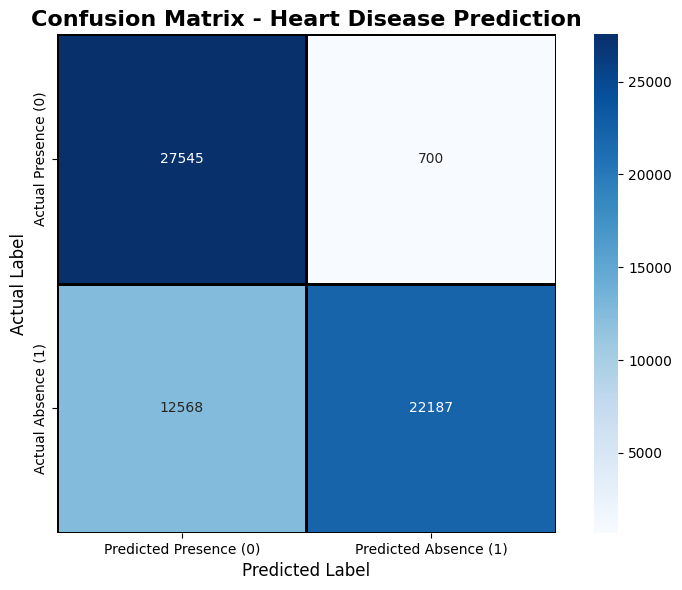

In [216]:
cm = confusion_matrix(y_test,y_pred_custom)

# Create the visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,           # Show numbers in cells
            fmt='d',               # Integer format
            cmap='Blues',          # Color scheme
            cbar=True,             # Show color bar
            square=True,           # Square cells
            linewidths=1,          # Lines between cells
            linecolor='black',      # Line color
            
            xticklabels=['Predicted Presence (0)', 'Predicted Absence (1)'],
            yticklabels=['Actual Presence (0)', 'Actual Absence (1)'])
plt.title('Confusion Matrix - Heart Disease Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()